# Volatility-day influence analysis for the state-dependent liquidity model

This notebook asks whether the activity-tail result is broadly distributed
across the sample or disproportionately influenced by a small number of
high-volatility UTC days. It is an influence analysis, not an outlier-cleaning
exercise: the full sample remains the preferred estimate, and deleting days
changes the estimand.

The notebook:

1. constructs the 4,000-event and five-minute bars once from the complete
   transaction sample;
2. describes daily returns, ranges, activity-tail observations and their
   concentration across days;
3. refits only the state-dependent logarithmic benchmark and its activity-tail
   extension under a small set of prespecified deletion scenarios; and
4. compares deletion estimates with the full-sample day-block-bootstrap
   interval from `StateDependentEffectiveLiquidity.ipynb` when available.

Conventional within-cell standard errors are used only as fitting weights and
descriptive residual scales. They are not treated as serial-dependence-robust
test statistics.

In [13]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
from numpy.polynomial.legendre import leggauss
import pandas as pd
from scipy.optimize import least_squares

%matplotlib inline

NOTEBOOK_DIR = Path.cwd()
default_project = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
PROJECT_DIR = Path(os.environ.get('CRYPTO_IMPACT_PROJECT_DIR', default_project)).resolve()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from src.crypto_impact.impact import add_trailing_impact_normalisation
from src.crypto_impact.monthly_eda import (
    build_fixed_event_bars,
    load_monthly_trades,
    make_time_bars,
)
from src.crypto_impact.regime_analysis import build_analysis_table

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.float_format', lambda value: f'{value:,.6f}')

## Configuration

Edit only the user-selection entries below to add or remove a particular set
of UTC days. Dates must use `YYYY-MM-DD`. An empty list means that no custom
scenario is added. Setting `AUTOMATIC_RANGE_QUANTILE` to (for example) `0.99`
adds a custom scenario that removes all days at or above that daily-range
quantile.

The standard influence scenarios remain enabled by default: the largest-range
days are removed one at a time, the largest three are removed jointly, and
the upper one per cent of daily ranges are removed jointly. These estimates
are sensitivity diagnostics; none replaces the all-days estimate.

In [14]:
CUSTOM_EXCLUDED_DATES = []
CUSTOM_SCENARIO_NAME = 'custom_dates'
AUTOMATIC_RANGE_QUANTILE = None

EVENTS_PER_BAR = int(os.environ.get('CRYPTO_IMPACT_EVENTS_PER_BAR', '4000'))
TIME_WINDOW = '5min'
TRAILING_WINDOW = '1D'
MIN_TRAILING_BARS = 100
N_ACTIVITY_BINS = 5
N_IMBALANCE_BINS = 20
MIN_OBS_PER_CELL = int(os.environ.get('CRYPTO_IMPACT_MIN_OBS_PER_CELL', '50'))
N_QUADRATURE_NODES = 32
N_STARTS = int(os.environ.get('CRYPTO_IMPACT_N_STARTS', '8'))
FULL_SAMPLE_N_STARTS = max(16, N_STARTS)
N_LARGEST_SINGLE_DAY_DELETIONS = int(
    os.environ.get('CRYPTO_IMPACT_N_SINGLE_DAY_DELETIONS', '10')
)
COMBINED_LARGEST_DAYS = 3
UPPER_RANGE_FRACTION = 0.01
MAX_FILES_ENV = int(os.environ.get('CRYPTO_IMPACT_MAX_FILES', '0'))
MAX_FILES = MAX_FILES_ENV or None
REBUILD_BAR_CACHE = os.environ.get('CRYPTO_IMPACT_REBUILD_INFLUENCE_CACHE', '0') == '1'

DATA_DIR = PROJECT_DIR / 'data' / 'raw' / 'BTCUSDT_monthly'
CACHE_DIR = Path(os.environ.get(
    'CRYPTO_IMPACT_INFLUENCE_CACHE_DIR',
    PROJECT_DIR / 'data' / 'processed' / 'volatility_day_influence_cache',
))
FIGURE_DIR = Path(
    os.environ.get('CRYPTO_IMPACT_FIGURE_DIR', PROJECT_DIR / 'reports' / 'figures')
)
TABLE_DIR = Path(
    os.environ.get('CRYPTO_IMPACT_TABLE_DIR', PROJECT_DIR / 'reports' / 'tables')
)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

files = sorted(DATA_DIR.glob('BTCUSDT-trades-*.parquet'))
if MAX_FILES is not None:
    files = files[:MAX_FILES]
if not files:
    raise FileNotFoundError(f'No monthly parquet files found in {DATA_DIR}')

# Increment when bar construction or normalisation logic changes. This prevents
# a cache made under an older implementation from silently changing the sample.
CACHE_SCHEMA_VERSION = 'v2'
CACHE_TAG = (
    f'{CACHE_SCHEMA_VERSION}_{files[0].stem}_{files[-1].stem}_'
    f'{EVENTS_PER_BAR}_event_{TIME_WINDOW}'
)
EVENT_CACHE = CACHE_DIR / f'{CACHE_TAG}_event_analysis.parquet'
TIME_CACHE = CACHE_DIR / f'{CACHE_TAG}_time_analysis.parquet'
DAILY_CACHE = CACHE_DIR / f'{CACHE_TAG}_daily_market.parquet'
SCALE_CACHE = CACHE_DIR / f'{CACHE_TAG}_normalisation.csv'
OUTPUT_STEM = f'volatility_day_influence_{EVENTS_PER_BAR}_event'

print(f'Files selected: {len(files)} ({files[0].name} to {files[-1].name})')
print(
    f'Fit starts per model: {FULL_SAMPLE_N_STARTS} for all-days; '
    f'{N_STARTS} for deletion scenarios'
)
print(f'Custom exclusions: {CUSTOM_EXCLUDED_DATES or "none"}')

Files selected: 17 (BTCUSDT-trades-2025-01.parquet to BTCUSDT-trades-2026-05.parquet)
Fit starts per model: 16 for all-days; 8 for deletion scenarios
Custom exclusions: none


## Construct or load the fixed bar samples

Bars and trailing normalisations are constructed from the complete transaction
record before any deletion is applied. This is important for the event-bar
construction: deleting raw trades first would move all subsequent 4,000-event
boundaries and would confound day influence with a different bar definition.

The full-sample imbalance and activity scales are also frozen across deletion
scenarios, so that the transformed parameters remain comparable. Quantile-bin
boundaries are rebuilt within each deletion sample, as they would be when the
model is re-estimated on that sample.

In [15]:
def prepare_normalised_analysis(bars):
    analysis = build_analysis_table(bars, horizons=())
    analysis = add_trailing_impact_normalisation(
        analysis,
        window=TRAILING_WINDOW,
        min_periods=MIN_TRAILING_BARS,
        timestamp_col='end_time',
    ).replace([np.inf, -np.inf], np.nan)
    start_time = pd.Series(
        pd.to_datetime(analysis.index, utc=True), index=analysis.index
    )
    end_time = pd.to_datetime(analysis['end_time'], utc=True)
    # A fixed-time bar ending exactly at midnight belongs to the preceding day.
    last_included_time = end_time - pd.Timedelta(nanoseconds=1)
    analysis['observation_day'] = start_time.dt.floor('D').to_numpy()
    analysis['last_observation_day'] = last_included_time.dt.floor('D').to_numpy()
    # Retain the same bootstrap block definition as the main model notebook.
    analysis['block_day'] = end_time.dt.floor('D')
    analysis['event_intensity'] = (
        analysis['trade_count'] / analysis['duration_seconds']
    )
    return analysis


def add_model_scales(data, scales=None):
    result = data.copy()
    valid = result[[
        'normalised_imbalance', 'normalised_signed_impact',
        'event_intensity', 'flow_rate_ratio',
    ]].replace([np.inf, -np.inf], np.nan).dropna()
    valid = valid.loc[
        (valid['normalised_imbalance'] > 0)
        & (valid['event_intensity'] > 0)
        & (valid['flow_rate_ratio'] > 0)
    ]
    if scales is None:
        scales = {
            'x_med': float(valid['normalised_imbalance'].median()),
            'event_intensity_median': float(valid['event_intensity'].median()),
            'relative_flow_ratio_median': float(valid['flow_rate_ratio'].median()),
        }
    result['imbalance_u'] = result['normalised_imbalance'] / scales['x_med']
    result['activity_z'] = np.log(
        result['event_intensity'] / scales['event_intensity_median']
    )
    result['relative_flow_f'] = np.log(
        result['flow_rate_ratio'] / scales['relative_flow_ratio_median']
    )
    result = result.replace([np.inf, -np.inf], np.nan).dropna(subset=[
        'imbalance_u', 'normalised_signed_impact', 'activity_z',
        'relative_flow_f', 'block_day', 'observation_day',
        'last_observation_day',
    ])
    return result.loc[result['imbalance_u'] > 0].copy(), scales


def daily_market_from_time_bars(time_bars):
    daily_source = time_bars.copy()
    daily_source['observation_day'] = pd.to_datetime(
        daily_source.index, utc=True
    ).floor('D')
    daily = (
        daily_source.groupby('observation_day', observed=True)
        .agg(
            open_price=('start_price', 'first'),
            close_price=('end_price', 'last'),
            high_price=('high_price', 'max'),
            low_price=('low_price', 'min'),
            trades=('trade_count', 'sum'),
            gross_volume_btc=('gross_volume', 'sum'),
            five_minute_bars=('trade_count', 'size'),
        )
        .reset_index()
    )
    daily['daily_log_return_pct'] = 100 * np.log(
        daily['close_price'] / daily['open_price']
    )
    daily['absolute_daily_log_return_pct'] = daily['daily_log_return_pct'].abs()
    daily['intraday_log_range_pct'] = 100 * np.log(
        daily['high_price'] / daily['low_price']
    )
    return daily.sort_values('observation_day').reset_index(drop=True)


cache_paths = [EVENT_CACHE, TIME_CACHE, DAILY_CACHE, SCALE_CACHE]
use_cache = all(path.exists() for path in cache_paths) and not REBUILD_BAR_CACHE

if use_cache:
    event_analysis = pd.read_parquet(EVENT_CACHE)
    time_analysis = pd.read_parquet(TIME_CACHE)
    daily_market = pd.read_parquet(DAILY_CACHE)
    normalisation_table = pd.read_csv(SCALE_CACHE, index_col='construction')
    event_scales = normalisation_table.loc['event_bars'].to_dict()
    time_scales = normalisation_table.loc['time_bars'].to_dict()
    print('Loaded prepared bar samples from cache.')
else:
    event_bars = build_fixed_event_bars(files, events_per_bar=EVENTS_PER_BAR)
    event_analysis, event_scales = add_model_scales(
        prepare_normalised_analysis(event_bars)
    )

    time_frames = []
    for path in files:
        monthly = make_time_bars(load_monthly_trades(path), window=TIME_WINDOW)
        monthly['start_time'] = monthly.index
        monthly['end_time'] = monthly.index + pd.Timedelta(TIME_WINDOW)
        monthly['duration_seconds'] = pd.Timedelta(TIME_WINDOW).total_seconds()
        monthly['source_file'] = path.name
        time_frames.append(monthly)
    time_bars = pd.concat(time_frames).sort_index()
    if not time_bars.index.is_unique:
        raise ValueError('Five-minute bar start times are not unique.')
    daily_market = daily_market_from_time_bars(time_bars)
    time_analysis, time_scales = add_model_scales(
        prepare_normalised_analysis(time_bars)
    )

    normalisation_table = pd.DataFrame({
        'event_bars': event_scales,
        'time_bars': time_scales,
    }).T
    normalisation_table.index.name = 'construction'
    event_analysis.to_parquet(EVENT_CACHE)
    time_analysis.to_parquet(TIME_CACHE)
    daily_market.to_parquet(DAILY_CACHE, index=False)
    normalisation_table.to_csv(SCALE_CACHE)
    print('Constructed and cached prepared bar samples.')

analysis_samples = {
    'event_bars': event_analysis,
    'time_bars': time_analysis,
}

sample_summary = pd.DataFrame([
    {
        'construction': construction,
        'observations': len(sample),
        'first_bar_start': pd.to_datetime(sample.index, utc=True).min(),
        'last_bar_start': pd.to_datetime(sample.index, utc=True).max(),
        'UTC_observation_days': sample['observation_day'].nunique(),
    }
    for construction, sample in analysis_samples.items()
])
sample_summary

Constructed and cached prepared bar samples.


,construction,observations,first_bar_start,last_bar_start,UTC_observation_days
0,event_bars,111576,2025-01-01 17:13:02.534000+00:00,2026-05-30 15:40:55.718000+00:00,506
1,time_bars,148505,2025-01-01 08:20:00+00:00,2026-05-31 23:55:00+00:00,516


## Daily market statistics

Daily ranges are calculated from the first, last, highest and lowest BTCUSDT
transaction prices in each UTC day. They are used to rank days, not to label
observations as erroneous. The main sample remains complete.

In [16]:
daily_market = daily_market.sort_values('observation_day').reset_index(drop=True)
daily_market['range_rank_descending'] = daily_market[
    'intraday_log_range_pct'
].rank(method='first', ascending=False).astype(int)
range_cutoff_99 = daily_market['intraday_log_range_pct'].quantile(0.99)
daily_market['upper_one_percent_range'] = (
    daily_market['intraday_log_range_pct'] >= range_cutoff_99
)

daily_distribution_summary = pd.Series({
    'first_UTC_day': daily_market['observation_day'].min(),
    'last_UTC_day': daily_market['observation_day'].max(),
    'UTC_days': len(daily_market),
    'missing_calendar_days': len(
        pd.date_range(
            daily_market['observation_day'].min(),
            daily_market['observation_day'].max(),
            freq='D', tz='UTC',
        ).difference(daily_market['observation_day'])
    ),
    'median_intraday_range_pct': daily_market['intraday_log_range_pct'].median(),
    'p95_intraday_range_pct': daily_market['intraday_log_range_pct'].quantile(0.95),
    'p99_intraday_range_pct': range_cutoff_99,
    'days_range_at_least_10_pct': int(
        (daily_market['intraday_log_range_pct'] >= 10).sum()
    ),
    'days_absolute_return_at_least_10_pct': int(
        (daily_market['absolute_daily_log_return_pct'] >= 10).sum()
    ),
})
daily_distribution_summary

first_UTC_day                           2025-01-01 00:00:00+00:00
last_UTC_day                            2026-05-31 00:00:00+00:00
UTC_days                                                      516
missing_calendar_days                                           0
median_intraday_range_pct                                3.023854
p95_intraday_range_pct                                   7.575952
p99_intraday_range_pct                                  11.055035
days_range_at_least_10_pct                                      9
days_absolute_return_at_least_10_pct                            2
dtype: object

In [17]:
daily_market.nlargest(15, 'intraday_log_range_pct')[[
    'observation_day', 'daily_log_return_pct', 'intraday_log_range_pct',
    'trades', 'gross_volume_btc', 'range_rank_descending',
]]

,observation_day,daily_log_return_pct,intraday_log_range_pct,trades,gross_volume_btc,range_rank_descending
282,2025-10-10 00:00:00+00:00,-7.570593,18.715680,1876923,"366,126.646000",1
401,2026-02-06 00:00:00+00:00,11.520484,18.168590,2956840,"559,182.769000",2
400,2026-02-05 00:00:00+00:00,-15.130235,16.389273,3576719,"670,089.741000",3
33,2025-02-03 00:00:00+00:00,3.648608,11.709233,2475928,"455,088.034000",4
98,2025-04-09 00:00:00+00:00,7.921767,11.358292,2155556,"560,649.862000",5
60,2025-03-02 00:00:00+00:00,9.122642,11.073018,1682117,"364,711.538000",6
395,2026-01-31 00:00:00+00:00,-6.766301,10.953128,1518858,"271,548.496000",7
61,2025-03-03 00:00:00+00:00,-8.907053,10.426453,2141995,"436,032.402000",8
19,2025-01-20 00:00:00+00:00,0.919739,10.031267,2736240,"530,508.180000",9
427,2026-03-04 00:00:00+00:00,6.169552,9.474137,1840051,"357,143.496000",10


## Concentration of the relevant market states across days

Two definitions are reported. `high_high` means that both activity and
absolute normalized imbalance exceed their full-sample 80th percentiles.
`top_surface_cell` is narrower: it is the highest imbalance vingtile within
the highest activity quintile used to construct the fitted response surface.

In [18]:
def assign_surface_bins(data):
    sample = data.copy()
    sample['activity_bin'] = pd.qcut(
        sample['activity_z'], q=N_ACTIVITY_BINS,
        labels=False, duplicates='drop',
    )
    if sample['activity_bin'].nunique() != N_ACTIVITY_BINS:
        raise ValueError('Insufficient distinct activity values for five quintiles.')
    frames = []
    for _, group in sample.groupby('activity_bin', observed=True):
        group = group.copy()
        group['imbalance_bin'] = pd.qcut(
            group['imbalance_u'], q=N_IMBALANCE_BINS,
            labels=False, duplicates='drop',
        )
        frames.append(group)
    return pd.concat(frames).sort_index()


daily_concentration_frames = []
for construction, sample in analysis_samples.items():
    assigned = assign_surface_bins(sample)
    activity_cutoff = sample['activity_z'].quantile(0.80)
    imbalance_cutoff = sample['imbalance_u'].quantile(0.80)
    assigned['high_high'] = (
        (assigned['activity_z'] > activity_cutoff)
        & (assigned['imbalance_u'] > imbalance_cutoff)
    )
    assigned['top_surface_cell'] = (
        (assigned['activity_bin'] == N_ACTIVITY_BINS - 1)
        & (assigned['imbalance_bin'] == N_IMBALANCE_BINS - 1)
    )
    daily = (
        assigned.groupby('observation_day', observed=True)
        .agg(
            bars=('normalised_signed_impact', 'size'),
            high_high_bars=('high_high', 'sum'),
            top_surface_cell_bars=('top_surface_cell', 'sum'),
            mean_normalised_signed_impact=('normalised_signed_impact', 'mean'),
        )
        .reset_index()
    )
    daily['high_high_share_of_day'] = daily['high_high_bars'] / daily['bars']
    daily['top_surface_cell_share_of_day'] = (
        daily['top_surface_cell_bars'] / daily['bars']
    )
    daily['share_of_all_high_high_bars'] = (
        daily['high_high_bars'] / daily['high_high_bars'].sum()
    )
    daily['share_of_all_top_surface_cell_bars'] = (
        daily['top_surface_cell_bars'] / daily['top_surface_cell_bars'].sum()
    )
    daily.insert(0, 'construction', construction)
    daily_concentration_frames.append(daily)

daily_state_concentration = pd.concat(
    daily_concentration_frames, ignore_index=True
).merge(
    daily_market[[
        'observation_day', 'daily_log_return_pct', 'intraday_log_range_pct',
        'range_rank_descending',
    ]],
    on='observation_day', how='left', validate='many_to_one',
)

daily_state_concentration.sort_values(
    ['construction', 'share_of_all_high_high_bars'],
    ascending=[True, False],
).groupby('construction', observed=True).head(10)

,construction,observation_day,bars,high_high_bars,top_surface_cell_bars,mean_normalised_signed_impact,high_high_share_of_day,top_surface_cell_share_of_day,share_of_all_high_high_bars,share_of_all_top_surface_cell_bars,daily_log_return_pct,intraday_log_range_pct,range_rank_descending
276,event_bars,2025-10-10 00:00:00+00:00,470,71,13,0.043917,0.151064,0.027660,0.012395,0.011649,-7.570593,18.715680,1
58,event_bars,2025-03-02 00:00:00+00:00,420,66,10,0.044628,0.157143,0.023810,0.011522,0.008961,9.122642,11.073018,6
93,event_bars,2025-04-06 00:00:00+00:00,309,53,4,0.064673,0.171521,0.012945,0.009253,0.003584,-6.322331,8.293063,17
12,event_bars,2025-01-13 00:00:00+00:00,427,50,5,0.039570,0.117096,0.011710,0.008729,0.004480,-0.015451,7.595464,25
26,event_bars,2025-01-27 00:00:00+00:00,466,46,6,0.042558,0.098712,0.012876,0.008031,0.005376,-0.526638,5.510630,64
479,event_bars,2026-05-04 00:00:00+00:00,278,45,12,0.046278,0.161871,0.043165,0.007856,0.010753,1.638254,3.324336,228
22,event_bars,2025-01-23 00:00:00+00:00,492,43,8,0.037782,0.087398,0.016260,0.007507,0.007168,0.191973,5.411465,69
386,event_bars,2026-01-31 00:00:00+00:00,380,42,11,0.032070,0.110526,0.028947,0.007332,0.009857,-6.766301,10.953128,7
138,event_bars,2025-05-21 00:00:00+00:00,413,41,2,0.034223,0.099274,0.004843,0.007158,0.001792,2.596612,4.411069,125
328,event_bars,2025-12-01 00:00:00+00:00,401,41,8,0.037317,0.102244,0.019950,0.007158,0.007168,-4.621180,7.577877,26


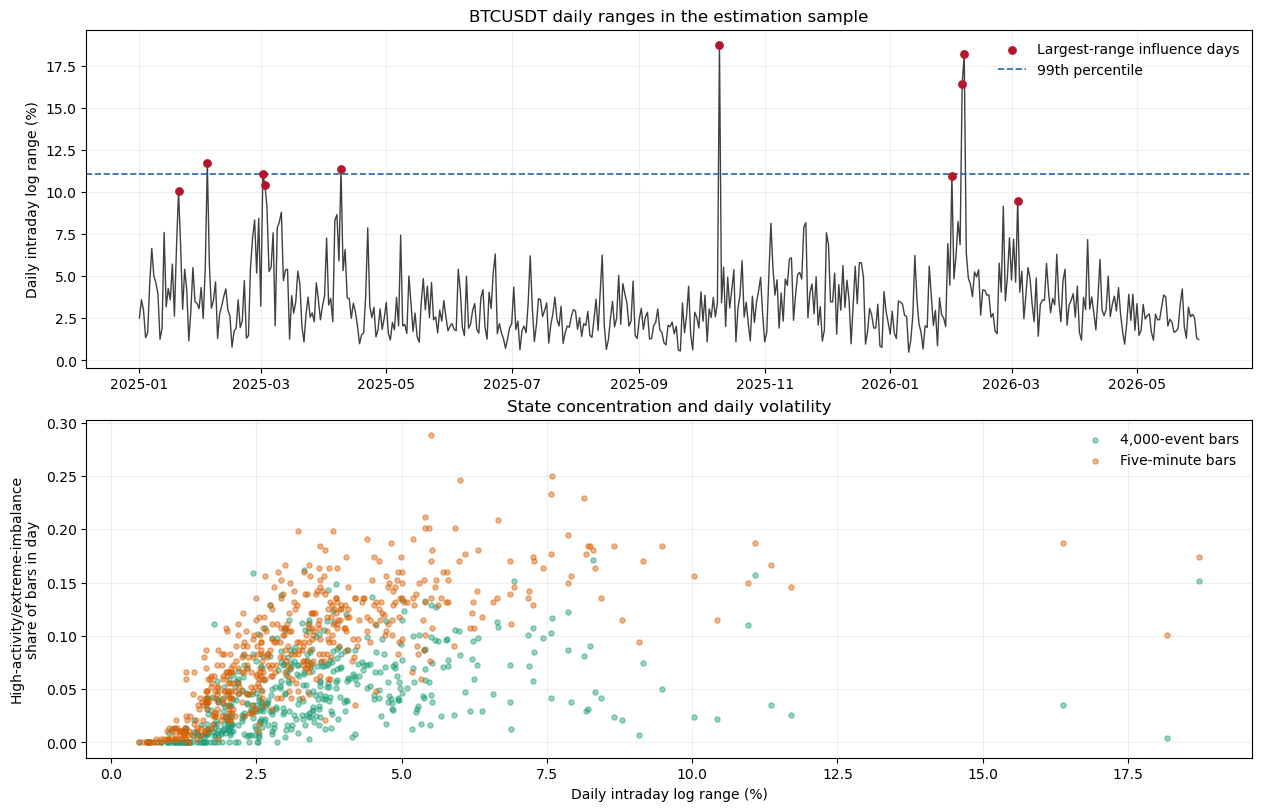

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(12.5, 8.0), constrained_layout=True)
axes[0].plot(
    daily_market['observation_day'], daily_market['intraday_log_range_pct'],
    color='0.25', lw=1.0,
)
largest_days = daily_market.nsmallest(
    N_LARGEST_SINGLE_DAY_DELETIONS, 'range_rank_descending'
)
axes[0].scatter(
    largest_days['observation_day'], largest_days['intraday_log_range_pct'],
    color='#b2182b', s=28, zorder=3, label='Largest-range influence days',
)
axes[0].axhline(
    range_cutoff_99, color='#2166ac', ls='--', lw=1.2,
    label='99th percentile',
)
axes[0].set_ylabel('Daily intraday log range (%)')
axes[0].set_title('BTCUSDT daily ranges in the estimation sample')
axes[0].legend(frameon=False)
axes[0].grid(alpha=0.20)

colours = {'event_bars': '#1b9e77', 'time_bars': '#d95f02'}
labels = {'event_bars': '4,000-event bars', 'time_bars': 'Five-minute bars'}
for construction, group in daily_state_concentration.groupby(
    'construction', observed=True
):
    axes[1].scatter(
        group['intraday_log_range_pct'], group['high_high_share_of_day'],
        s=14, alpha=0.45, color=colours[construction],
        label=labels[construction],
    )
axes[1].set_xlabel('Daily intraday log range (%)')
axes[1].set_ylabel('High-activity/extreme-imbalance\nshare of bars in day')
axes[1].set_title('State concentration and daily volatility')
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.20)

overview_figure_path = FIGURE_DIR / f'{OUTPUT_STEM}_overview.pdf'
fig.savefig(overview_figure_path, bbox_inches='tight')
plt.show()

## Prespecified deletion scenarios

The all-days scenario is always estimated. Standard scenarios delete the
largest-range days individually, the largest three jointly, and the upper one
per cent jointly. Custom dates and an optional automatic quantile rule are
added without replacing these standard comparisons. Duplicate scenarios are
removed automatically.

In [20]:
def utc_day(value):
    timestamp = pd.Timestamp(value)
    if timestamp.tzinfo is None:
        timestamp = timestamp.tz_localize('UTC')
    else:
        timestamp = timestamp.tz_convert('UTC')
    return timestamp.floor('D')


def add_scenario(container, name, selection_rule, dates):
    normalized = tuple(sorted({utc_day(value) for value in dates}))
    key = normalized
    if key not in {scenario['excluded_dates'] for scenario in container}:
        container.append({
            'scenario': name,
            'selection_rule': selection_rule,
            'excluded_dates': normalized,
        })


scenario_specs = []
add_scenario(scenario_specs, 'all_days', 'none', [])

ranked_days = daily_market.sort_values('intraday_log_range_pct', ascending=False)
for row in ranked_days.head(N_LARGEST_SINGLE_DAY_DELETIONS).itertuples():
    date_label = row.observation_day.strftime('%Y-%m-%d')
    add_scenario(
        scenario_specs,
        f'drop_{date_label}',
        f'single day; daily-range rank {row.range_rank_descending}',
        [row.observation_day],
    )

add_scenario(
    scenario_specs,
    f'drop_largest_{COMBINED_LARGEST_DAYS}_range_days',
    f'largest {COMBINED_LARGEST_DAYS} daily ranges',
    ranked_days.head(COMBINED_LARGEST_DAYS)['observation_day'],
)
add_scenario(
    scenario_specs,
    'drop_upper_1pct_range_days',
    'intraday range at or above full-sample 99th percentile',
    daily_market.loc[
        daily_market['upper_one_percent_range'], 'observation_day'
    ],
)

if CUSTOM_EXCLUDED_DATES:
    add_scenario(
        scenario_specs, CUSTOM_SCENARIO_NAME,
        'user-specified UTC dates', CUSTOM_EXCLUDED_DATES,
    )

if AUTOMATIC_RANGE_QUANTILE is not None:
    if not 0 < AUTOMATIC_RANGE_QUANTILE < 1:
        raise ValueError('AUTOMATIC_RANGE_QUANTILE must lie strictly between 0 and 1.')
    cutoff = daily_market['intraday_log_range_pct'].quantile(
        AUTOMATIC_RANGE_QUANTILE
    )
    add_scenario(
        scenario_specs,
        f'drop_range_q{AUTOMATIC_RANGE_QUANTILE:.3f}',
        f'intraday range at or above quantile {AUTOMATIC_RANGE_QUANTILE:.3f}',
        daily_market.loc[
            daily_market['intraday_log_range_pct'] >= cutoff,
            'observation_day',
        ],
    )

scenario_definitions = pd.DataFrame([
    {
        'scenario': spec['scenario'],
        'selection_rule': spec['selection_rule'],
        'excluded_day_count': len(spec['excluded_dates']),
        'excluded_dates': ';'.join(
            value.strftime('%Y-%m-%d') for value in spec['excluded_dates']
        ),
    }
    for spec in scenario_specs
])
scenario_definitions

,scenario,selection_rule,excluded_day_count,excluded_dates
0,all_days,none,0,
1,drop_2025-10-10,single day; daily-range rank 1,1,2025-10-10
2,drop_2026-02-06,single day; daily-range rank 2,1,2026-02-06
3,drop_2026-02-05,single day; daily-range rank 3,1,2026-02-05
4,drop_2025-02-03,single day; daily-range rank 4,1,2025-02-03
5,drop_2025-04-09,single day; daily-range rank 5,1,2025-04-09
6,drop_2025-03-02,single day; daily-range rank 6,1,2025-03-02
7,drop_2026-01-31,single day; daily-range rank 7,1,2026-01-31
8,drop_2025-03-03,single day; daily-range rank 8,1,2025-03-03
9,drop_2025-01-20,single day; daily-range rank 9,1,2025-01-20


## Conditional response surface and parsimonious models

Only three fits are required computationally: the pooled logarithmic response
supplies starting values, while the reported comparison is between the
four-parameter state-dependent logarithmic response and the seven-parameter
activity-tail extension. Each deletion fit starts from the all-days solution.

In [21]:
def build_response_surface(data):
    columns = [
        'imbalance_u', 'activity_z', 'relative_flow_f',
        'normalised_signed_impact', 'block_day',
    ]
    sample = data.loc[:, columns].replace([np.inf, -np.inf], np.nan).dropna()
    sample = sample.loc[sample['imbalance_u'] > 0].copy()
    sample['activity_bin'] = pd.qcut(
        sample['activity_z'], q=N_ACTIVITY_BINS,
        labels=False, duplicates='drop',
    )
    if sample['activity_bin'].nunique() != N_ACTIVITY_BINS:
        raise ValueError('Insufficient distinct activity values for five quintiles.')

    frames = []
    for activity_bin, group in sample.groupby('activity_bin', observed=True):
        group = group.copy()
        group['imbalance_bin'] = pd.qcut(
            group['imbalance_u'], q=N_IMBALANCE_BINS,
            labels=False, duplicates='drop',
        )
        if group['imbalance_bin'].nunique() != N_IMBALANCE_BINS:
            raise ValueError(
                f'Insufficient distinct imbalance values in activity bin {activity_bin}.'
            )
        cell = (
            group.groupby('imbalance_bin', observed=True)
            .agg(
                mean_u=('imbalance_u', 'mean'),
                median_u=('imbalance_u', 'median'),
                mean_z=('activity_z', 'mean'),
                median_z=('activity_z', 'median'),
                mean_f=('relative_flow_f', 'mean'),
                median_f=('relative_flow_f', 'median'),
                mean_impact=('normalised_signed_impact', 'mean'),
                median_impact=('normalised_signed_impact', 'median'),
                impact_std=('normalised_signed_impact', 'std'),
                n_obs=('normalised_signed_impact', 'count'),
                n_days=('block_day', 'nunique'),
            )
            .reset_index()
        )
        cell.insert(0, 'activity_bin', int(activity_bin))
        frames.append(cell)
    surface = pd.concat(frames, ignore_index=True)
    surface['standard_error'] = surface['impact_std'] / np.sqrt(surface['n_obs'])
    surface = surface.loc[
        (surface['n_obs'] >= MIN_OBS_PER_CELL)
        & np.isfinite(surface['standard_error'])
        & (surface['standard_error'] > 0)
    ].copy()
    surface['activity_bin'] = surface['activity_bin'].astype(int)
    surface['imbalance_bin'] = surface['imbalance_bin'].astype(int)
    return surface.sort_values(['activity_bin', 'imbalance_bin'])


QUAD_NODES, QUAD_WEIGHTS = leggauss(N_QUADRATURE_NODES)
MODEL_ORDER = ['pooled_log', 'state_log', 'activity_tail']
PARAMETER_NAMES = {
    'pooled_log': ['log_A', 'log_u0'],
    'state_log': ['log_A', 'A_activity_slope', 'log_u0', 'u0_activity_slope'],
    'activity_tail': [
        'log_A', 'A_activity_slope', 'log_u0', 'u0_activity_slope',
        'gamma_activity', 'activity_threshold_z', 'log_imbalance_threshold_u',
    ],
}


def central_parameters(params, z):
    A = np.exp(params[0] + params[1] * z)
    u0 = np.exp(params[2] + params[3] * z)
    return A, u0


def tail_response(u, z, f, params):
    u = np.asarray(u, dtype=float)
    z = np.asarray(z, dtype=float)
    A, u0 = central_parameters(params, z)
    gamma_z, z_star, log_u_star = params[4:7]
    u_star = np.exp(log_u_star)
    kappa = gamma_z * np.maximum(z - z_star, 0.0)

    central_end = np.minimum(u, u_star)
    central_response = A * np.log1p(central_end / u0)
    tail_width = np.maximum(u - u_star, 0.0)
    nodes = u_star + 0.5 * tail_width[:, None] * (
        QUAD_NODES[None, :] + 1.0
    )
    h = np.log(nodes / u_star)
    exponent = np.clip(kappa[:, None] * h, 0.0, 30.0)
    integrand = A[:, None] * np.exp(exponent) / (u0[:, None] + nodes)
    tail_value = 0.5 * tail_width * np.sum(
        QUAD_WEIGHTS[None, :] * integrand, axis=1
    )
    no_adjustment = kappa <= 1e-12
    exact_log_tail = A * (
        np.log1p(u / u0) - np.log1p(central_end / u0)
    )
    tail_value = np.where(no_adjustment, exact_log_tail, tail_value)
    return central_response + tail_value


def predict_model(model, params, data):
    u = np.asarray(data['mean_u'], dtype=float)
    z = np.asarray(data['mean_z'], dtype=float)
    f = np.asarray(data['mean_f'], dtype=float)
    if model == 'pooled_log':
        A, u0 = np.exp(params)
        return A * np.log1p(u / u0)
    if model == 'state_log':
        A, u0 = central_parameters(params, z)
        return A * np.log1p(u / u0)
    if model == 'activity_tail':
        return tail_response(u, z, f, params)
    raise ValueError(f'Unknown model: {model}')


def parameter_bounds(model, surface):
    z = surface['mean_z'].to_numpy()
    u = surface['mean_u'].to_numpy()
    central_lower = [-12.0, -3.0, -7.0, -3.0]
    central_upper = [2.0, 3.0, 7.0, 3.0]
    if model == 'pooled_log':
        return np.array([-12.0, -7.0]), np.array([2.0, 7.0])
    if model == 'state_log':
        return np.array(central_lower), np.array(central_upper)
    return (
        np.array([
            *central_lower, 0.0, np.quantile(z, 0.10),
            np.log(np.quantile(u, 0.40)),
        ]),
        np.array([
            *central_upper, 5.0, np.quantile(z, 0.95),
            np.log(np.quantile(u, 0.995)),
        ]),
    )


def initial_parameters(model, surface, previous_fits):
    if model == 'pooled_log':
        positive = surface.loc[surface['mean_impact'] > 0, 'mean_impact']
        A0 = float(positive.median()) if len(positive) else 0.03
        return np.log([max(A0, 1e-4), 1.0])
    if model == 'state_log':
        pooled = previous_fits['pooled_log']['params']
        return np.array([pooled[0], 0.0, pooled[1], 0.0])
    central = previous_fits['state_log']['params']
    return np.array([
        *central, 0.15,
        surface['mean_z'].quantile(0.80),
        np.log(surface['mean_u'].quantile(0.90)),
    ])


def fit_one_model(
    model, surface, previous_fits, *, initial_override=None,
    n_starts=N_STARTS, random_state=0,
):
    data = surface.replace([np.inf, -np.inf], np.nan).dropna(subset=[
        'mean_u', 'mean_z', 'mean_f', 'mean_impact', 'standard_error',
    ]).copy()
    lower, upper = parameter_bounds(model, data)
    initial = (
        np.asarray(initial_override, dtype=float)
        if initial_override is not None
        else initial_parameters(model, data, previous_fits)
    )
    initial = np.clip(initial, lower + 1e-8, upper - 1e-8)
    sigma = data['standard_error'].to_numpy(dtype=float)
    fallback = np.median(sigma[np.isfinite(sigma) & (sigma > 0)])
    sigma = np.where(np.isfinite(sigma) & (sigma > 0), sigma, fallback)
    y = data['mean_impact'].to_numpy(dtype=float)

    def residuals(params):
        return (y - predict_model(model, params, data)) / sigma

    rng = np.random.default_rng(random_state)
    starts = [initial]
    for _ in range(max(1, n_starts) - 1):
        draw = initial + rng.normal(0.0, 0.15, len(initial)) * (upper - lower)
        starts.append(np.clip(draw, lower + 1e-7, upper - 1e-7))

    best = None
    for start in starts:
        result = least_squares(
            residuals, start, bounds=(lower, upper), max_nfev=25_000,
            xtol=1e-10, ftol=1e-10, gtol=1e-10,
        )
        if best is None or np.sum(result.fun**2) < np.sum(best.fun**2):
            best = result
    prediction = predict_model(model, best.x, data)
    return {
        'model': model,
        'params': best.x,
        'lower_bounds': lower,
        'upper_bounds': upper,
        'success': bool(best.success),
        'weighted_sum_squared_residuals': float(np.sum(best.fun**2)),
        'data': data,
        'prediction': prediction,
        'residual': y - prediction,
    }


def fit_model_sequence(surface, *, reference_fits=None, n_starts=N_STARTS, random_state=0):
    fits = {}
    for model_number, model in enumerate(MODEL_ORDER):
        initial_override = None
        if reference_fits is not None:
            initial_override = reference_fits[model]['params']
        fits[model] = fit_one_model(
            model, surface, fits, initial_override=initial_override,
            n_starts=n_starts, random_state=random_state + model_number,
        )
    return fits


def weighted_rmse(residual, standard_error):
    weights = 1.0 / np.asarray(standard_error, dtype=float)**2
    residual = np.asarray(residual, dtype=float)
    return float(np.sqrt(np.sum(weights * residual**2) / np.sum(weights)))


def fit_summary_row(fit):
    data = fit['data']
    residual = fit['residual']
    tail = data['imbalance_bin'] == data['imbalance_bin'].max()
    high_tail = tail & (data['activity_bin'] == data['activity_bin'].max())
    tolerance = 1e-4 * (fit['upper_bounds'] - fit['lower_bounds'])
    at_bound = (
        (fit['params'] - fit['lower_bounds'] <= tolerance)
        | (fit['upper_bounds'] - fit['params'] <= tolerance)
    )
    names = np.asarray(PARAMETER_NAMES[fit['model']])[at_bound]
    high_tail_residual = residual[high_tail]
    high_tail_se = data.loc[high_tail, 'standard_error'].to_numpy()
    return {
        'model': fit['model'],
        'parameters': len(fit['params']),
        'cells': len(data),
        'weighted_rmse': weighted_rmse(residual, data['standard_error']),
        'tail_weighted_rmse': weighted_rmse(
            residual[tail], data.loc[tail, 'standard_error']
        ),
        'high_activity_tail_weighted_rmse': weighted_rmse(
            high_tail_residual, high_tail_se
        ),
        'unweighted_rmse': float(np.sqrt(np.mean(residual**2))),
        'weighted_sum_squared_residuals': fit['weighted_sum_squared_residuals'],
        'high_activity_final_cell_residual': float(high_tail_residual[0]),
        'high_activity_final_cell_conventional_standardised_residual': float(
            high_tail_residual[0] / high_tail_se[0]
        ),
        'parameters_at_bound': int(at_bound.sum()),
        'bound_parameter_names': ';'.join(names),
        'converged': fit['success'],
    }


def transformed_parameters(model, params):
    values = dict(zip(PARAMETER_NAMES[model], params))
    output = {
        'A_at_median_activity': np.exp(values['log_A']),
        'u0_at_median_activity': np.exp(values['log_u0']),
    }
    if model != 'pooled_log':
        output.update({
            'A_activity_slope': values['A_activity_slope'],
            'u0_activity_slope': values['u0_activity_slope'],
        })
    if model == 'activity_tail':
        output.update({
            'gamma_activity': values['gamma_activity'],
            'activity_threshold_z': values['activity_threshold_z'],
            'activity_threshold_multiple': np.exp(values['activity_threshold_z']),
            'imbalance_threshold_u': np.exp(values['log_imbalance_threshold_u']),
        })
    return output

## Fit all influence scenarios

A bar is removed if its observation interval overlaps an excluded UTC day.
Event-bar and time-bar partitions, trailing normalisations and full-sample
scaling constants otherwise remain fixed.

In [22]:
def scenario_sample(data, excluded_dates):
    if not excluded_dates:
        return data.copy()
    excluded = set(excluded_dates)
    keep = ~(
        data['observation_day'].isin(excluded)
        | data['last_observation_day'].isin(excluded)
    )
    return data.loc[keep].copy()


fit_rows = []
parameter_rows = []
scenario_sample_rows = []
baseline_fits = {}

for construction_number, (construction, full_sample) in enumerate(
    analysis_samples.items()
):
    for scenario_number, spec in enumerate(scenario_specs):
        selected = scenario_sample(full_sample, spec['excluded_dates'])
        surface = build_response_surface(selected)
        reference = baseline_fits.get(construction)
        scenario_n_starts = (
            FULL_SAMPLE_N_STARTS
            if spec['scenario'] == 'all_days'
            else N_STARTS
        )
        fits = fit_model_sequence(
            surface, reference_fits=reference,
            n_starts=scenario_n_starts,
            random_state=(40_000 + construction_number * 10_000 + scenario_number * 100),
        )
        if spec['scenario'] == 'all_days':
            baseline_fits[construction] = fits

        scenario_sample_rows.append({
            'construction': construction,
            'scenario': spec['scenario'],
            'excluded_day_count': len(spec['excluded_dates']),
            'excluded_dates': ';'.join(
                value.strftime('%Y-%m-%d') for value in spec['excluded_dates']
            ),
            'observations': len(selected),
            'observations_removed': len(full_sample) - len(selected),
            'fraction_observations_removed': 1 - len(selected) / len(full_sample),
            'surface_cells': len(surface),
        })
        for model in ['state_log', 'activity_tail']:
            fit_rows.append({
                'construction': construction,
                'scenario': spec['scenario'],
                **fit_summary_row(fits[model]),
            })
            parameter_rows.append({
                'construction': construction,
                'scenario': spec['scenario'],
                'model': model,
                **transformed_parameters(model, fits[model]['params']),
            })

scenario_samples = pd.DataFrame(scenario_sample_rows)
influence_fit_statistics = pd.DataFrame(fit_rows)
influence_parameters = pd.DataFrame(parameter_rows)

key_rows = []
for (construction, scenario), fits in influence_fit_statistics.groupby(
    ['construction', 'scenario'], observed=True
):
    indexed = fits.set_index('model')
    parameters = influence_parameters.loc[
        (influence_parameters['construction'] == construction)
        & (influence_parameters['scenario'] == scenario)
        & (influence_parameters['model'] == 'activity_tail')
    ].iloc[0]
    sample_row = scenario_samples.loc[
        (scenario_samples['construction'] == construction)
        & (scenario_samples['scenario'] == scenario)
    ].iloc[0]
    key_rows.append({
        'construction': construction,
        'scenario': scenario,
        'excluded_day_count': sample_row['excluded_day_count'],
        'excluded_dates': sample_row['excluded_dates'],
        'observations': sample_row['observations'],
        'fraction_observations_removed': sample_row['fraction_observations_removed'],
        'gamma_activity': parameters['gamma_activity'],
        'activity_threshold_multiple': parameters['activity_threshold_multiple'],
        'imbalance_threshold_u': parameters['imbalance_threshold_u'],
        'state_log_weighted_rmse': indexed.loc['state_log', 'weighted_rmse'],
        'activity_tail_weighted_rmse': indexed.loc['activity_tail', 'weighted_rmse'],
        'weighted_rmse_improvement_pct': 100 * (
            indexed.loc['state_log', 'weighted_rmse']
            - indexed.loc['activity_tail', 'weighted_rmse']
        ) / indexed.loc['state_log', 'weighted_rmse'],
        'state_log_tail_weighted_rmse': indexed.loc[
            'state_log', 'tail_weighted_rmse'
        ],
        'activity_tail_tail_weighted_rmse': indexed.loc[
            'activity_tail', 'tail_weighted_rmse'
        ],
        'tail_weighted_rmse_improvement_pct': 100 * (
            indexed.loc['state_log', 'tail_weighted_rmse']
            - indexed.loc['activity_tail', 'tail_weighted_rmse']
        ) / indexed.loc['state_log', 'tail_weighted_rmse'],
        'activity_tail_parameters_at_bound': indexed.loc[
            'activity_tail', 'parameters_at_bound'
        ],
        'activity_tail_bound_parameter_names': indexed.loc[
            'activity_tail', 'bound_parameter_names'
        ],
    })

key_influence_results = pd.DataFrame(key_rows).merge(
    scenario_definitions[['scenario', 'selection_rule']],
    on='scenario', how='left', validate='many_to_one',
)

for construction in key_influence_results['construction'].unique():
    baseline = key_influence_results.loc[
        (key_influence_results['construction'] == construction)
        & (key_influence_results['scenario'] == 'all_days')
    ].iloc[0]
    mask = key_influence_results['construction'] == construction
    key_influence_results.loc[mask, 'gamma_change_from_all_days'] = (
        key_influence_results.loc[mask, 'gamma_activity']
        - baseline['gamma_activity']
    )
    key_influence_results.loc[mask, 'gamma_ratio_to_all_days'] = (
        key_influence_results.loc[mask, 'gamma_activity']
        / baseline['gamma_activity']
    )
    key_influence_results.loc[
        mask, 'tail_improvement_change_from_all_days_pct_points'
    ] = (
        key_influence_results.loc[mask, 'tail_weighted_rmse_improvement_pct']
        - baseline['tail_weighted_rmse_improvement_pct']
    )

key_influence_results.sort_values(['construction', 'scenario'])

,construction,scenario,excluded_day_count,excluded_dates,observations,fraction_observations_removed,gamma_activity,activity_threshold_multiple,imbalance_threshold_u,state_log_weighted_rmse,activity_tail_weighted_rmse,weighted_rmse_improvement_pct,state_log_tail_weighted_rmse,activity_tail_tail_weighted_rmse,tail_weighted_rmse_improvement_pct,activity_tail_parameters_at_bound,activity_tail_bound_parameter_names,selection_rule,gamma_change_from_all_days,gamma_ratio_to_all_days,tail_improvement_change_from_all_days_pct_points
0,event_bars,all_days,0,,111576,0.000000,0.134364,0.386402,0.756671,0.001733,0.001395,19.505359,0.004893,0.002468,49.568300,0,,none,0.000000,1.000000,0.000000
1,event_bars,drop_2025-01-20,1,2025-01-20,110891,0.006139,0.134811,0.385671,0.760971,0.001742,0.001414,18.835142,0.004920,0.002636,46.413695,1,log_imbalance_threshold_u,single day; daily-range rank 9,0.000447,1.003327,-3.154605
2,event_bars,drop_2025-02-03,1,2025-02-03,110956,0.005557,0.136284,0.385776,0.759236,0.001730,0.001382,20.121530,0.004990,0.002676,46.368709,1,log_imbalance_threshold_u,single day; daily-range rank 4,0.001920,1.014289,-3.199591
3,event_bars,drop_2025-03-02,1,2025-03-02,111155,0.003773,0.134221,0.385935,0.754649,0.001729,0.001391,19.578565,0.004899,0.002482,49.347734,1,log_imbalance_threshold_u,single day; daily-range rank 6,-0.000143,0.998932,-0.220566
4,event_bars,drop_2025-03-03,1,2025-03-03,111039,0.004813,0.134780,0.385746,0.759461,0.001726,0.001386,19.684743,0.004949,0.002644,46.581213,1,log_imbalance_threshold_u,single day; daily-range rank 8,0.000416,1.003093,-2.987087
5,event_bars,drop_2025-04-09,1,2025-04-09,111036,0.004840,0.134818,0.385746,0.758088,0.001736,0.001402,19.239448,0.004912,0.002655,45.942678,1,log_imbalance_threshold_u,single day; daily-range rank 5,0.000454,1.003376,-3.625622
6,event_bars,drop_2025-10-10,1,2025-10-10,111105,0.004221,0.133672,0.386199,0.757057,0.001728,0.001392,19.430942,0.005045,0.002617,48.125095,1,log_imbalance_threshold_u,single day; daily-range rank 1,-0.000692,0.994848,-1.443205
7,event_bars,drop_2026-01-31,1,2026-01-31,111195,0.003415,0.132793,0.386129,0.756413,0.001728,0.001401,18.909284,0.004780,0.002460,48.530109,1,log_imbalance_threshold_u,single day; daily-range rank 7,-0.001572,0.988304,-1.038191
8,event_bars,drop_2026-02-05,1,2026-02-05,110681,0.008021,0.129747,0.385463,0.771125,0.001765,0.001484,15.936766,0.004998,0.002950,40.978589,1,log_imbalance_threshold_u,single day; daily-range rank 3,-0.004617,0.965635,-8.589711
9,event_bars,drop_2026-02-06,1,2026-02-06,110836,0.006632,0.132981,0.385537,0.768697,0.001754,0.001434,18.229368,0.005068,0.002782,45.114963,1,log_imbalance_threshold_u,single day; daily-range rank 2,-0.001384,0.989703,-4.453337


## Influence plots

The grey band is the existing full-sample UTC-day block-bootstrap interval for
\(\gamma\), if that output is available. It is a reference scale rather than
a hypothesis test for deletion estimates. The lower panels show the **in-sample**
reduction in tail weighted RMSE from adding the activity-tail mechanism. Here the
tail contains only the highest-imbalance cell in each of the five activity
quintiles. A large percentage can therefore result when the restricted state-log
fit misses one extreme cell and the three-parameter extension absorbs that
residual. It is not a proportion of returns explained and should be interpreted
alongside the blocked out-of-sample results in the main model notebook.

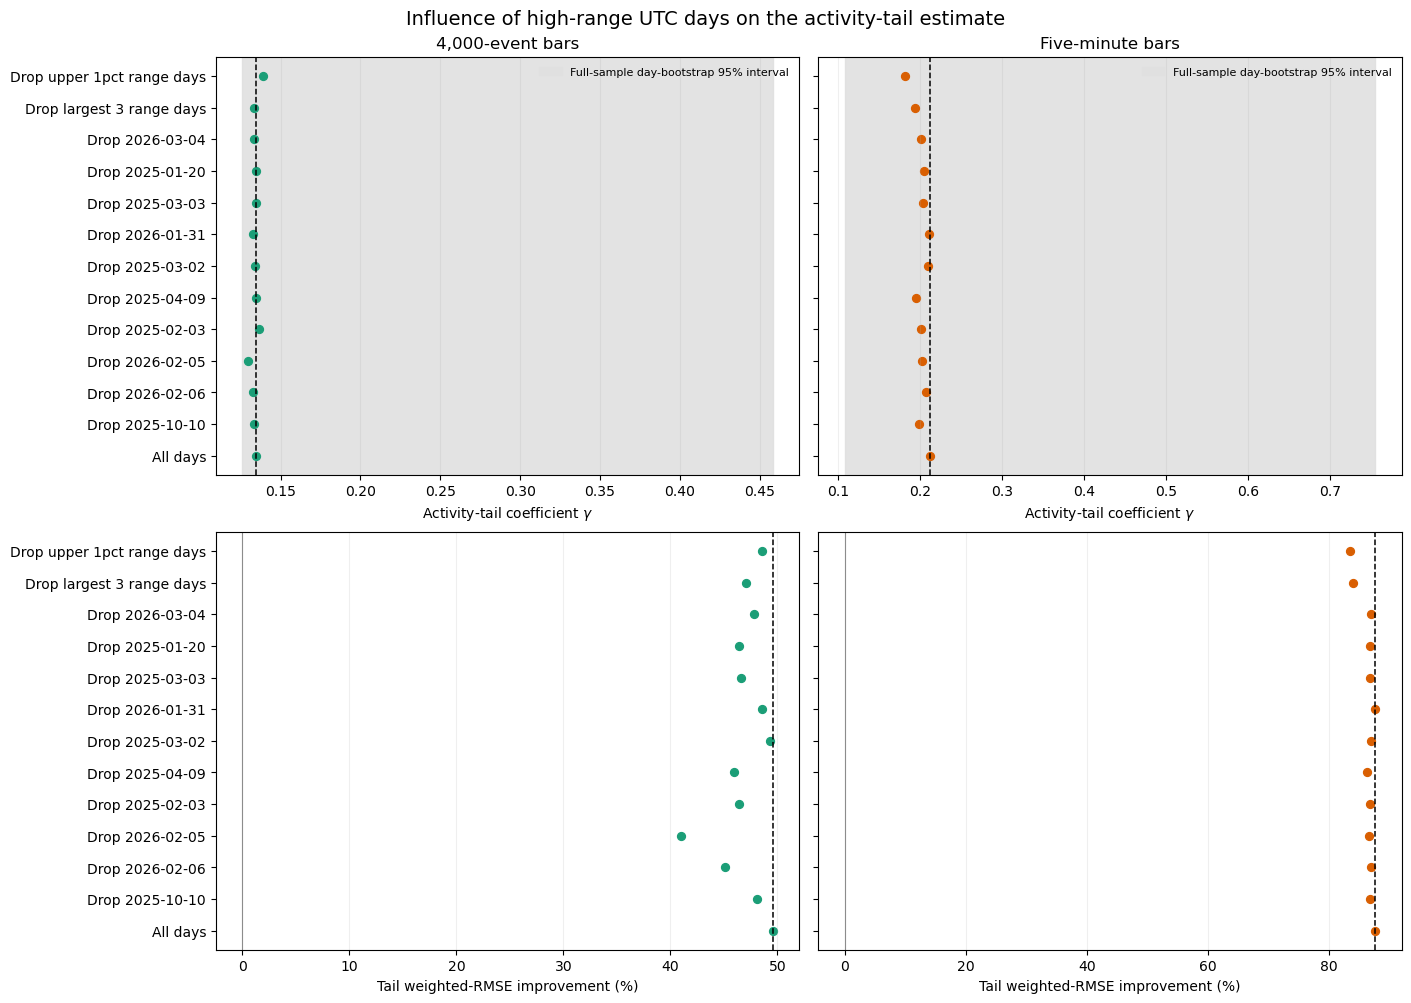

In [23]:
bootstrap_path = TABLE_DIR / 'state_dependent_liquidity_bootstrap_summary.csv'
bootstrap_reference = None
if bootstrap_path.exists():
    bootstrap_reference = pd.read_csv(bootstrap_path).set_index('construction')

scenario_order = scenario_definitions['scenario'].tolist()
scenario_labels = {
    row.scenario: (
        'All days' if row.scenario == 'all_days'
        else row.scenario.replace('drop_', 'Drop ').replace('_', ' ')
    )
    for row in scenario_definitions.itertuples()
}

fig, axes = plt.subplots(
    2, 2, figsize=(14.0, max(8.5, 0.34 * len(scenario_order) + 5.5)),
    sharey='row', constrained_layout=True,
)

for column, construction in enumerate(['event_bars', 'time_bars']):
    data = (
        key_influence_results.loc[
            key_influence_results['construction'] == construction
        ]
        .set_index('scenario')
        .reindex(scenario_order)
    )
    y = np.arange(len(data))
    gamma_ax = axes[0, column]
    improvement_ax = axes[1, column]

    if bootstrap_reference is not None and construction in bootstrap_reference.index:
        reference = bootstrap_reference.loc[construction]
        gamma_ax.axvspan(
            reference['gamma_p025'], reference['gamma_p975'],
            color='0.88', alpha=0.9, label='Full-sample day-bootstrap 95% interval',
        )
    baseline_gamma = data.loc['all_days', 'gamma_activity']
    gamma_ax.axvline(baseline_gamma, color='black', ls='--', lw=1.1)
    gamma_ax.scatter(data['gamma_activity'], y, color=colours[construction], s=32)
    gamma_ax.set_xlabel(r'Activity-tail coefficient $\gamma$')
    gamma_ax.set_title(labels[construction])
    gamma_ax.grid(axis='x', alpha=0.20)
    if column == 0:
        gamma_ax.set_yticks(y, [scenario_labels[value] for value in data.index])
    if bootstrap_reference is not None:
        gamma_ax.legend(frameon=False, fontsize=8, loc='best')

    baseline_improvement = data.loc[
        'all_days', 'tail_weighted_rmse_improvement_pct'
    ]
    improvement_ax.axvline(
        baseline_improvement, color='black', ls='--', lw=1.1
    )
    improvement_ax.scatter(
        data['tail_weighted_rmse_improvement_pct'], y,
        color=colours[construction], s=32,
    )
    improvement_ax.axvline(0, color='0.55', lw=0.8)
    improvement_ax.set_xlabel('Tail weighted-RMSE improvement (%)')
    improvement_ax.grid(axis='x', alpha=0.20)
    if column == 0:
        improvement_ax.set_yticks(y, [scenario_labels[value] for value in data.index])

fig.suptitle(
    'Influence of high-range UTC days on the activity-tail estimate', fontsize=14
)
influence_figure_path = FIGURE_DIR / f'{OUTPUT_STEM}_estimates.pdf'
fig.savefig(influence_figure_path, bbox_inches='tight')
plt.show()

## Save reproducible outputs

In [24]:
sample_summary.to_csv(TABLE_DIR / f'{OUTPUT_STEM}_sample_summary.csv', index=False)
daily_market.to_csv(TABLE_DIR / f'{OUTPUT_STEM}_daily_market.csv', index=False)
daily_state_concentration.to_csv(
    TABLE_DIR / f'{OUTPUT_STEM}_daily_state_concentration.csv', index=False
)
scenario_definitions.to_csv(
    TABLE_DIR / f'{OUTPUT_STEM}_scenario_definitions.csv', index=False
)
scenario_samples.to_csv(
    TABLE_DIR / f'{OUTPUT_STEM}_scenario_samples.csv', index=False
)
influence_fit_statistics.to_csv(
    TABLE_DIR / f'{OUTPUT_STEM}_fit_statistics.csv', index=False
)
influence_parameters.to_csv(
    TABLE_DIR / f'{OUTPUT_STEM}_parameters.csv', index=False
)
key_influence_results.to_csv(
    TABLE_DIR / f'{OUTPUT_STEM}_key_results.csv', index=False
)

print('Overview figure:', overview_figure_path)
print('Influence figure:', influence_figure_path)
print('Tables:', TABLE_DIR / f'{OUTPUT_STEM}_*.csv')

Overview figure: /Users/petermillington/research/market-impact-research/crypto-impact-study/reports/figures/volatility_day_influence_4000_event_overview.pdf
Influence figure: /Users/petermillington/research/market-impact-research/crypto-impact-study/reports/figures/volatility_day_influence_4000_event_estimates.pdf
Tables: /Users/petermillington/research/market-impact-research/crypto-impact-study/reports/tables/volatility_day_influence_4000_event_*.csv


## Interpretation checklist

1. **Do not redefine the preferred sample.** The all-days estimate remains the
   primary estimate because volatile days are part of the phenomenon of
   interest.
2. **Check concentration before coefficients.** A high-range day can contain
   many high/high bars without dominating the full set of such observations.
3. **Read deletion estimates as influence diagnostics.** Deleting days selected
   using realized volatility conditions on an outcome related to the response
   mechanism and therefore changes the estimand.
4. **Distinguish existence from threshold precision.** Stable positive
   \(\gamma\) with variable \(z_\ast\) or \(u_\ast\) means that the tail
   adjustment is more robust than its precise onset.
5. **Escalate only material changes.** If a prespecified deletion changes the
   substantive conclusion, rerun the UTC-day block bootstrap for that scenario.
   Otherwise the point-estimate influence table is sufficient.
6. **Interpret concentration substantively.** If 10 October 2025 has unusually
   large influence, that is evidence that liquidation-cascade conditions may
   be important, not evidence that the observation should be discarded.